importing neccessary libraries

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

verifying the imports worked

In [19]:
import sys
import tensorflow as tf

print(sys.executable)
print(tf.__version__)

c:\Users\Sumanth\AppData\Local\Python\pythoncore-3.10-64\python.exe
2.15.0


dataset path


In [20]:
dataset_path = "C:\\Users\\Sumanth\\Documents\\projects\\data science project\\classification_dataset"

In [21]:
for cls in os.listdir(dataset_path):
    print(cls, len(os.listdir(os.path.join(dataset_path, cls))))

crab 378
dolphin 50
jellyfish 961
octopus 50
seahorse 50
seal 464
seaturtle 1003
shark 640
squid 483
starfish 688


building model

In [22]:
# Separate datagens — augmentation ONLY for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,       # only rescale, no augmentation
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=16,
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=16,
    subset='validation'
)

Found 3817 images belonging to 10 classes.
Found 950 images belonging to 10 classes.


In [23]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['crab', 'dolphin', 'jellyfish', 'octopus', 'seahorse', 'seal', 'seaturtle', 'shark', 'squid', 'starfish']


In [24]:
# Build model
base_model = MobileNetV2(
      input_shape=(224, 224, 3),
      include_top=False, 
      weights='imagenet'
      )
base_model.trainable = False   # freeze first

In [25]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

compile model

In [26]:
model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy'])


train model

In [27]:
# Phase 1 — train top layers only
print("Phase 1: Training top layers...")
history1 = model.fit(
           train_data, 
           validation_data=val_data, 
           epochs=10)

Phase 1: Training top layers...
Epoch 1/10
239/239 [==============================] - 66s 268ms/step - loss: 0.7660 - accuracy: 0.7708 - val_loss: 0.3610 - val_accuracy: 0.8800
Epoch 2/10
239/239 [==============================] - 61s 255ms/step - loss: 0.4569 - accuracy: 0.8538 - val_loss: 0.3224 - val_accuracy: 0.8968
Epoch 3/10
239/239 [==============================] - 61s 255ms/step - loss: 0.4058 - accuracy: 0.8666 - val_loss: 0.2700 - val_accuracy: 0.9116
Epoch 4/10
239/239 [==============================] - 61s 256ms/step - loss: 0.3808 - accuracy: 0.8763 - val_loss: 0.2988 - val_accuracy: 0.8926
Epoch 5/10
239/239 [==============================] - 61s 257ms/step - loss: 0.3340 - accuracy: 0.8910 - val_loss: 0.2889 - val_accuracy: 0.9032
Epoch 6/10
239/239 [==============================] - 61s 255ms/step - loss: 0.3011 - accuracy: 0.8973 - val_loss: 0.2609 - val_accuracy: 0.9137
Epoch 7/10
239/239 [==============================] - 61s 256ms/step - loss: 0.2838 - accuracy: 0.

In [28]:
# Phase 2 — unfreeze and fine-tune
print("Phase 2: Fine-tuning...")
base_model.trainable = True
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history2 = model.fit(train_data, validation_data=val_data, epochs=10)

Phase 2: Fine-tuning...
Epoch 1/10
239/239 [==============================] - 164s 650ms/step - loss: 0.7185 - accuracy: 0.7781 - val_loss: 0.2879 - val_accuracy: 0.9158
Epoch 2/10
239/239 [==============================] - 154s 644ms/step - loss: 0.4595 - accuracy: 0.8473 - val_loss: 0.2660 - val_accuracy: 0.9168
Epoch 3/10
239/239 [==============================] - 154s 644ms/step - loss: 0.3819 - accuracy: 0.8729 - val_loss: 0.2552 - val_accuracy: 0.9158
Epoch 4/10
239/239 [==============================] - 154s 644ms/step - loss: 0.3581 - accuracy: 0.8839 - val_loss: 0.2609 - val_accuracy: 0.9147
Epoch 5/10
239/239 [==============================] - 154s 644ms/step - loss: 0.3467 - accuracy: 0.8858 - val_loss: 0.2579 - val_accuracy: 0.9168
Epoch 6/10
239/239 [==============================] - 153s 642ms/step - loss: 0.3183 - accuracy: 0.8978 - val_loss: 0.2521 - val_accuracy: 0.9158
Epoch 7/10
239/239 [==============================] - 191s 800ms/step - loss: 0.3080 - accuracy: 0.8

plot the results

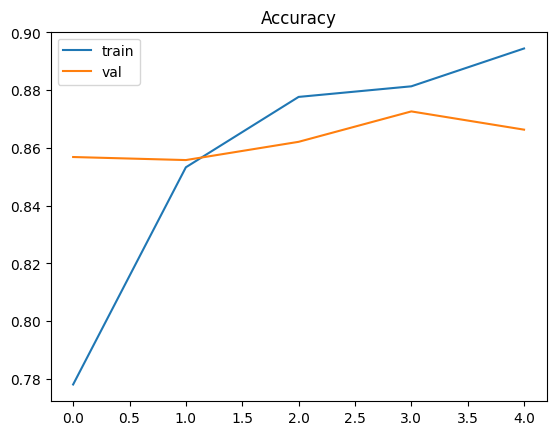

In [29]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

save model

In [30]:
model.save("C:\\Users\\Sumanth\\Documents\\projects\\Aquatic_classification_and_detection\\model\\aquatic_model_v2.keras")

In [31]:
loss, acc = model.evaluate(val_data)
print(f"Final Validation Accuracy: {acc:.2%}")

60/60 [==============================] - 10s 158ms/step - loss: 0.2481 - accuracy: 0.9221
Final Validation Accuracy: 92.21%
